<a href="https://colab.research.google.com/github/Chukzimmani/projects/blob/main/Gradient_Descent_From_Scratch_Math_With_Chukz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent, From Scratch

### Math With Chukz &mdash; the mathematics behind modern technology

Welcome, and thank you for downloading this notebook.

Here is a question to start with. When people say that a machine "learns," what does that word really mean? It sounds like magic, but it is not magic at all, and by the end of this short notebook you will have built the exact idea that sits underneath almost every kind of modern AI, using nothing but a little bit of Python.

The idea is called **gradient descent**, and the plan is simple. First you will *see it*, so that the picture makes sense in your head, and then you will *build it* yourself, line by line, with no library doing the hard part for you, and finally you will *prove it*, by watching your own code learn from real data right in front of you.

Let us begin.

> *I do not just teach mathematics &mdash; I show you why it works.*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# Math With Chukz house colours
NAVY  = "#0A1F44"
AMBER = "#F4B400"
RED   = "#C0392B"

# Use Poppins for the labels if it is installed, so the plots match the brand
for _f in font_manager.findSystemFonts():
    if "Poppins" in _f:
        font_manager.fontManager.addfont(_f)
try:
    plt.rcParams["font.family"] = "Poppins"
except Exception:
    pass

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   NAVY,
    "axes.labelcolor":  NAVY,
    "text.color":       NAVY,
    "xtick.color":      NAVY,
    "ytick.color":      NAVY,
    "axes.grid":        True,
    "grid.color":       "#e6e9f0",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

np.random.seed(7)
print("Setup complete. Let us go.")

Setup complete. Let us go.


## 1. See it &mdash; learning is just walking downhill

Imagine that you are standing somewhere on the side of a hill, and a thick fog has come down so that you cannot see the bottom of the valley at all. You still want to get down to the lowest point, so what do you do? Well, even though you cannot see very far, you can always feel which way the ground slopes under your feet, and so you take one small step in the downhill direction, and then you feel the ground again, and then you take another small step, and you keep going like this until the ground under you is flat and you cannot go any lower.

That is the whole idea of gradient descent, and it really is that simple.

In machine learning, the "hill" is a number that measures how wrong the machine is, and we call that number the **loss**. A high place on the hill means the machine is very wrong, and the bottom of the valley means it is as right as it can be. So when we say that a machine is learning, what we really mean is that it is walking downhill on this hill of mistakes, one small step at a time, trying to reach the bottom.

Let us draw a simple hill so that you can see it.

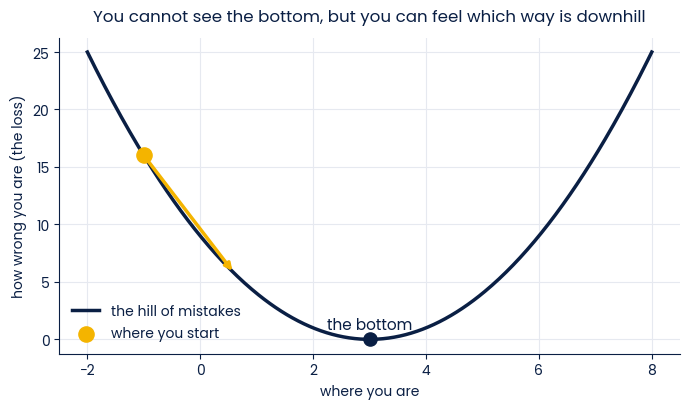

In [ ]:
# A simple hill (a valley) whose lowest point sits at x = 3
def f(x):
    return (x - 3)**2

xs = np.linspace(-2, 8, 400)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(xs, f(xs), color=NAVY, linewidth=2.5, label="the hill of mistakes")

start = -1.0
ax.scatter([start], [f(start)], color=AMBER, s=120, zorder=5, label="where you start")
ax.annotate("", xy=(start + 1.6, f(start + 1.6)), xytext=(start, f(start)),
            arrowprops=dict(arrowstyle="-|>", color=AMBER, lw=2.5))
ax.scatter([3], [0], color=NAVY, s=90, zorder=5)
ax.text(3, 0.9, "the bottom", ha="center", color=NAVY, fontsize=11)

ax.set_title("You cannot see the bottom, but you can feel which way is downhill",
             color=NAVY, fontsize=12, pad=12)
ax.set_xlabel("where you are")
ax.set_ylabel("how wrong you are (the loss)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 2. Build it &mdash; the slope is all you need

So how does the machine "feel" the ground under its feet? The trick is a piece of school mathematics called the slope, and in this setting we give the slope a slightly fancier name, the **gradient**. The slope simply tells you how much the hill goes up or down as you move a little to the side, and the sign of the slope tells you which way is uphill. Since we want to go downhill, we just step in the opposite direction to the slope, and that one sentence is the beating heart of how modern AI learns.

For our simple hill, which is the curve `(x - 3)**2`, the slope at any point `x` turns out to be `2 * (x - 3)`. You do not need to worry about where that comes from right now, so let us just use it and watch what happens.

Here is the recipe that you will follow again and again, where you look at where you are and measure the slope under your feet, and then you take one small step in the opposite direction to that slope, and then you repeat the whole thing until the ground is flat. The size of each step has a name too, and we call it the **learning rate**, because it decides how boldly the machine tries to learn.

Let us write this out in plain Python.

In [ ]:
def slope(x):
    # the slope of (x - 3)**2 at the point x
    return 2 * (x - 3)

x = -1.0             # where we start on the hill
learning_rate = 0.1  # the size of each small step

for step in range(1, 21):
    x = x - learning_rate * slope(x)      # take one small step downhill
    if step == 1 or step % 4 == 0:
        print(f"step {step:2d}:   x = {x:5.3f}    loss = {f(x):6.4f}")

print(f"\nWe ended near x = {x:.3f}, and the true bottom is at x = 3.")

step  1:   x = -0.200    loss = 10.2400
step  4:   x = 1.362    loss = 2.6844
step  8:   x = 2.329    loss = 0.4504
step 12:   x = 2.725    loss = 0.0756
step 16:   x = 2.887    loss = 0.0127
step 20:   x = 2.954    loss = 0.0021

We ended near x = 2.954, and the true bottom is at x = 3.


## 3. Build it again &mdash; now teach a line to fit real data

Walking down a hill is nice, but let us do something that actually feels like machine learning. We are going to hand the computer a cloud of data points, and we will ask it to find the straight line that fits through them, all on its own, using the very same downhill walk that you just wrote.

A straight line has two numbers that decide its shape, which are the slope of the line, `w`, and the height where it starts, `b`. At the beginning the computer does not know either of them, so it simply guesses, and its first line will be badly wrong. To measure how wrong it is, we look at every data point and see how far the line misses it, and then we square that miss so that it is always positive, and then we take the average over all the points. That average is our loss, the height on the hill, and the computer's whole job is to walk that number down toward the bottom by slowly changing `w` and `b`.

The slope of this loss, with respect to each of the two numbers, tells the computer how to nudge them, and here they are in plain terms, where `p` is the line's prediction and `y` is the true value, so that to update `w` the slope is the average of `2 * (p - y) * x`, and to update `b` the slope is the average of `2 * (p - y)`.

Let us make some data and let the machine learn.

In [ ]:
# Make some data that roughly follows the line y = 2*x + 5, with a little noise
N = 60
x_data = np.linspace(0, 10, N)
true_w, true_b = 2.0, 5.0
y_data = true_w * x_data + true_b + np.random.normal(0, 2.0, size=N)

# The machine starts with a bad guess and knows nothing
w, b = 0.0, 0.0
learning_rate = 0.01
loss_history = []

for step in range(400):
    p = w * x_data + b                 # the line's current prediction
    error = p - y_data                 # how far each point is missed
    loss = np.mean(error**2)           # how wrong we are overall
    loss_history.append(loss)

    grad_w = np.mean(2 * error * x_data)   # slope for w
    grad_b = np.mean(2 * error)            # slope for b

    w = w - learning_rate * grad_w         # one small step downhill
    b = b - learning_rate * grad_b

print(f"The machine learned:   w = {w:.2f},   b = {b:.2f}")
print(f"The real answer was:   w = {true_w:.2f},   b = {true_b:.2f}")

The machine learned:   w = 2.12,   b = 4.19
The real answer was:   w = 2.00,   b = 5.00


## 4. Prove it &mdash; watch the learning happen

The numbers above look close to the truth, but you should never just take my word for it, so let us look at two pictures that prove the machine really did learn.

The first picture shows the loss, which is our height on the hill, at every step of the walk, and if gradient descent is working then this line should slide downhill quickly and then flatten out near the bottom, which is the machine telling us that it has learned about as much as it can. The second picture shows the cloud of data together with the line that the machine found, so that you can see with your own eyes just how well it fits.

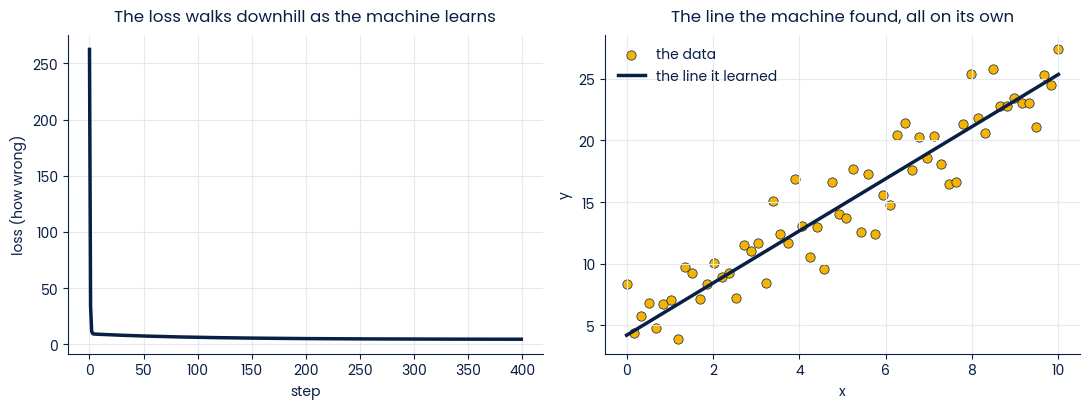

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# Left: the loss walking downhill
ax1.plot(loss_history, color=NAVY, linewidth=2.5)
ax1.set_title("The loss walks downhill as the machine learns",
              color=NAVY, fontsize=12, pad=10)
ax1.set_xlabel("step"); ax1.set_ylabel("loss (how wrong)")

# Right: the data and the line the machine found
ax2.scatter(x_data, y_data, color=AMBER, s=45, edgecolor=NAVY, linewidth=0.5, label="the data")
ax2.plot(x_data, w * x_data + b, color=NAVY, linewidth=2.5, label="the line it learned")
ax2.set_title("The line the machine found, all on its own",
              color=NAVY, fontsize=12, pad=10)
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.legend(frameon=False)

plt.tight_layout(); plt.show()

## 5. Try it yourself &mdash; the one setting that changes everything

There is one number in your code that matters more than any other, and that is the learning rate, the size of each step that you take downhill, and it is well worth playing with, because getting it wrong is one of the most common reasons that learning fails in real life.

Think about walking down the foggy hill again. If your steps are far too tiny, then you will still reach the bottom in the end, but it will take you a very long time to get there. If your steps are far too big, then you will leap right over the bottom of the valley and up the other side, and you may even bounce higher and higher until you fly off the hill completely. Somewhere in between there is a step size that is just right, and let us watch all three of them at once.

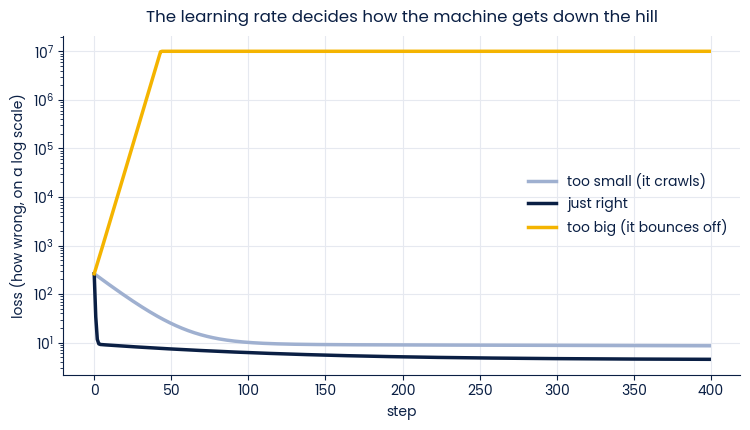

Change the three learning rates above, run the cell again, and see what happens.


In [ ]:
def train_line(learning_rate, steps=400):
    w, b, hist = 0.0, 0.0, []
    for _ in range(steps):
        p = w * x_data + b
        error = p - y_data
        hist.append(min(np.mean(error**2), 1e7))   # cap it so a runaway still plots
        w -= learning_rate * np.mean(2 * error * x_data)
        b -= learning_rate * np.mean(2 * error)
    return hist

fig, ax = plt.subplots(figsize=(7.6, 4.4))
for lr, colour, name in [(0.0004, "#9fb0d0", "too small (it crawls)"),
                         (0.01,   NAVY,      "just right"),
                         (0.031,  AMBER,     "too big (it bounces off)")]:
    ax.plot(train_line(lr), color=colour, linewidth=2.5, label=name)

ax.set_yscale("log")
ax.set_title("The learning rate decides how the machine gets down the hill",
             color=NAVY, fontsize=12, pad=10)
ax.set_xlabel("step"); ax.set_ylabel("loss (how wrong, on a log scale)")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print("Change the three learning rates above, run the cell again, and see what happens.")

## 6. The catch &mdash; what happens when the hill has more than one valley

Everything that you built today worked beautifully, and there is a quiet reason for that, which is that our hill had only one valley, so no matter where you started, walking downhill always carried you to the one true bottom.

But here is the twist that makes real AI so hard. The hills that a real neural network has to walk on are not smooth and simple like ours, and instead they are full of bumps, with many little valleys scattered all over the place. Some of those valleys are shallow dips that are not really the lowest point at all, and the trouble is that our simple downhill rule cannot tell the difference, because once it walks into any valley and the ground goes flat, it stops and believes that it is finished, even when a far deeper valley was waiting just over the next hill.

Let us look at one of these tricky hills, so that you can see the trap for yourself.

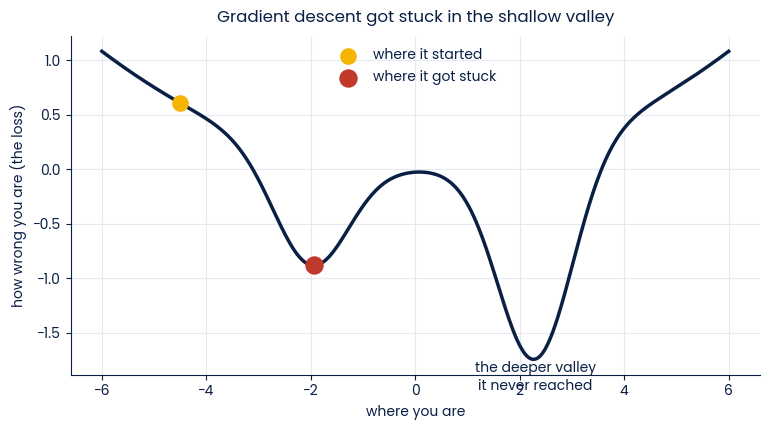

In [ ]:
# A bumpy hill: a shallow valley on the left, and a deeper valley on the right
def bumpy(x):
    return -1.0*np.exp(-(x + 2.0)**2) - 1.9*np.exp(-(x - 2.3)**2) + 0.03*x**2

def bumpy_slope(x, h=1e-4):
    # we measure the slope simply by nudging x a tiny bit and seeing how f changes
    return (bumpy(x + h) - bumpy(x - h)) / (2*h)

xs = np.linspace(-6, 6, 500)

# Start over on the left and walk downhill, one small step at a time
x = -4.5
lr = 0.25
path = [x]
for _ in range(120):
    x = x - lr * bumpy_slope(x)
    path.append(x)
path = np.array(path)

fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.plot(xs, bumpy(xs), color=NAVY, linewidth=2.5)
ax.scatter([path[0]],  [bumpy(path[0])],  color=AMBER, s=120, zorder=6, label="where it started")
ax.scatter([path[-1]], [bumpy(path[-1])], color=RED,   s=150, zorder=6, label="where it got stuck")
ax.text(2.3, bumpy(2.3) - 0.28, "the deeper valley\nit never reached",
        ha="center", color=NAVY, fontsize=10)
ax.set_title("Gradient descent got stuck in the shallow valley",
             color=NAVY, fontsize=12, pad=10)
ax.set_xlabel("where you are")
ax.set_ylabel("how wrong you are (the loss)")
ax.legend(frameon=False, loc="upper center")
plt.tight_layout(); plt.show()

## Where to go next

So you have now built the very engine that teaches machines to learn, and you have also met the exact problem that keeps engineers up at night, which is how to help gradient descent climb out of a shallow valley and find the deep one instead. That question is the whole story of my video, **"Why AI Gets Stuck &mdash; and the Math That Frees It,"** and I would love for you to watch it next, because it picks up right where this notebook stops. You will find it on the channel at **youtube.com/@mathwithchukz**.

And if you enjoyed building this from scratch, then you will feel right at home in **From Scratch**, my course where we build the real engines behind modern AI in this same gentle way, from the system that decides what you watch next, all the way to the tiny model that learns to talk like ChatGPT.

Thank you for spending this time with me, and please always remember that the machine is never really magic, because once you can see the mathematics underneath it, you can also see exactly why it works.

**&mdash; Chukz, Math With Chukz**

> *I do not just teach mathematics &mdash; I show you why it works.*